# This project is about predicting the car price based on the input features by Multiple Linear Regression.

## Problem Statement
A Chinese automobile company Geely Auto aspires to enter the US market by setting up their manufacturing unit there and producing cars locally to give competition to their US and European counterparts.

They have contracted an automobile consulting company to understand the factors on which the pricing of cars depends. Specifically, they want to understand the factors affecting the pricing of cars in the American market, since those may be very different from the Chinese market. The company wants to know:

Which variables are significant in predicting the price of a car
How well those variables describe the price of a car
Based on various market surveys, the consulting firm has gathered a large data set of different types of cars across the America market

## Business Goal
We are required to model the price of cars with the available independent variables. It will be used by the management to understand how exactly the prices vary with the independent variables. They can accordingly manipulate the design of the cars, the business strategy etc. to meet certain price levels. Further, the model will be a good way for management to understand the pricing dynamics of a new market.

In [218]:
import pandas as pd
import numpy as np


In [219]:
# loading the dataset 
data = pd.read_csv('CarPrice_Assignment.csv')
data

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [220]:
data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [221]:
data.tail()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0
204,205,-1,volvo 264gl,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625.0


In [222]:
data.sample()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
77,78,2,mitsubishi lancer,gas,std,two,hatchback,fwd,front,93.7,...,92,2bbl,2.97,3.23,9.4,68,5500,31,38,6189.0


In [223]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

# 1. Data Understanding / EDA
### Basic structure
1. How many rows and columns does the dataset have, and what are the data types of each column?

In [224]:
data.shape

(205, 26)

rows = 205, columns = 26

2. Are there any missing or null values in any column?

In [225]:
data.isna().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

No missing values in any columns.

3. Are there any duplicate rows?

In [226]:
data.duplicated().sum()

np.int64(0)

No any duplicates.

In [227]:
data.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [228]:
data_description = pd.read_excel('Car_Price_Data_Dictionary.xlsx')
data_description_clean = data_description.iloc[:, :3]
data_description_clean.columns = ['S.No', 'Column Name', 'Description']
print("Description about all the columns...\n")
print(df_clean.to_markdown(index=False))

Description about all the columns...

|   S.No | Column Name               | Description                                                                                                                          |
|-------:|:--------------------------|:-------------------------------------------------------------------------------------------------------------------------------------|
|      1 | Car_ID                    | Unique id of each observation (Interger)                                                                                             |
|      2 | Symboling                 | Its assigned insurance risk rating, A value of +3 indicates that the auto is risky, -3 that it is probably pretty safe.(Categorical) |
|      3 | carCompany                | Name of car company (Categorical)                                                                                                    |
|      4 | fueltype                  | Car fuel type i.e gas or diesel (Categorical)        

4. What does the statistical summary (mean, median, min, max, std) look like for numeric columns?

In [229]:
data.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


#### Target variable (price)
5. What is the distribution of price? Is it normally distributed or skewed?

Text(0.5, 1.0, 'Price Distribution ')

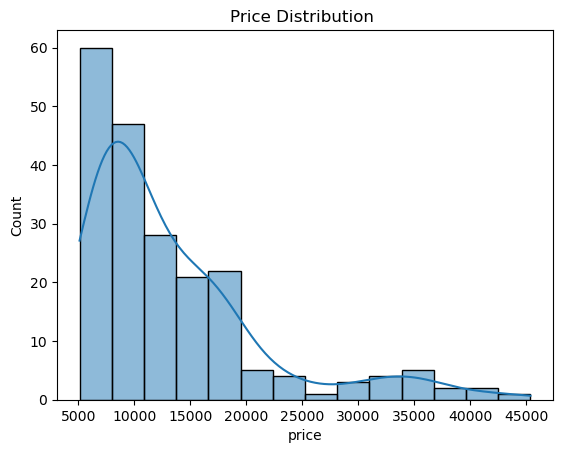

In [230]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=data,
    x= data['price'],
    kde = True
)
plt.title("Price Distribution ")

the distribution of price is heavily right-skewed (positively skewed). It is not normally distributed.

6. What are the minimum, maximum, and average car prices?

In [231]:
data['price'].describe()

count      205.000000
mean     13276.710571
std       7988.852332
min       5118.000000
25%       7788.000000
50%      10295.000000
75%      16503.000000
max      45400.000000
Name: price, dtype: float64

7. Are there any outliers in price?

In [232]:
# Calculate Q1, Q3, and IQR
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Filter outliers on both ends
outliers = data[(data['price'] < lower_bound) | (data['price'] > upper_bound)]

print(f"Lower Outlier Threshold: ${lower_bound:,.2f}")
print(f"Upper Outlier Threshold: ${upper_bound:,.2f}")
print(f"Total Outliers: {len(outliers)}")

Lower Outlier Threshold: $-5,284.50
Upper Outlier Threshold: $29,575.50
Total Outliers: 15


### Categorical variables
8. How many unique car companies are there? (Hint: CarName needs cleaning — it has company + model together, e.g. "alfa-romero giulia")

In [233]:
data['CarName']

0            alfa-romero giulia
1           alfa-romero stelvio
2      alfa-romero Quadrifoglio
3                   audi 100 ls
4                    audi 100ls
                 ...           
200             volvo 145e (sw)
201                 volvo 144ea
202                 volvo 244dl
203                   volvo 246
204                 volvo 264gl
Name: CarName, Length: 205, dtype: object

In [234]:
# 1. Extract the first word as company name (and convert to lowercase)
data['company'] = data['CarName'].apply(lambda x: x.split(' ')[0].lower())

# Check uncleaned unique count
print("Uncleaned Unique Companies:", data['company'].nunique())

# 2. Fix typos and brand name inconsistencies
corrections = {
    'maxda': 'mazda',
    'porcshz': 'porsche',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
    'toyouta': 'toyota',
}

data['company'] = data['company'].replace(corrections)

# 3. Final Clean Count
print("Cleaned Unique Companies:", data['company'].nunique())
print("Unique Companies List:\n", sorted(data['company'].unique()))

Uncleaned Unique Companies: 27
Cleaned Unique Companies: 23
Unique Companies List:
 ['alfa-romero', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porcshce', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo']


9. Which car company appears most frequently in the dataset?

In [237]:
data['company'].value_counts()

company
toyota         32
nissan         18
mazda          17
mitsubishi     13
honda          13
volkswagen     12
subaru         12
peugeot        11
volvo          11
dodge           9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
isuzu           4
porsche         4
jaguar          3
chevrolet       3
alfa-romero     3
renault         2
mercury         1
porcshce        1
Name: count, dtype: int64

In [241]:
data['company'].value_counts().idxmax()

'toyota'

Car company 'toyota' appears most frequently in the dataset.

10. What is the distribution of fueltype (gas vs diesel)? Does fuel type affect price?

/var/folders/d8/83r4k_r15tv7zl64z94ffs640000gn/T/ipykernel_48323/1287367610.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


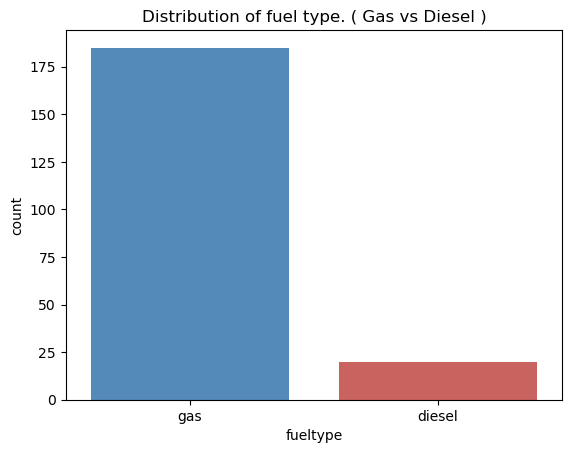

In [278]:
sns.countplot(
    data=data,
    x= data['fueltype'],
    palette=['#428bca', '#d9534f']
)
plt.title('Distribution of fuel type. ( Gas vs Diesel )')
plt.show()

from the figure we can see that the count of gas car are much higher then the diesel one which indicates that the gas car in high demands.

In [ ]:
data.groupby('fueltype')['price'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
fueltype,,,,
diesel,15838.1500,13852.5,7099.0,31600.0
gas,12999.7982,9989.0,5118.0,45400.0


we can see that the average price of gas car = 12999.7982 which is less then average price of diesel car = 15838.1500. Price of gas car is cheaper then diesel car in all comparison.

so we can say that fuel type affect the price of the car.

11. How does carbody (sedan, hatchback, convertible, etc.) relate to price?

In [251]:
data['carbody'].value_counts()

carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

In [252]:
data.groupby('carbody')['price'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
carbody,,,,
convertible,21890.500000,17084.5,11595.0,37028.0
hardtop,22208.500000,19687.5,8249.0,45400.0
hatchback,10376.652386,8897.0,5118.0,31400.5
sedan,14344.270833,10846.5,5499.0,41315.0
wagon,12371.960000,11694.0,6918.0,28248.0


Yes, carbody strongly impacts price.
- Luxury / Premium Tier: Hardtop and Convertible carbody style have higher average prices ($\approx \$21,800 - \$22,200$) compared to other body types.
- Mid-Tier: Sedan ($\approx \$14,344$) and Wagon ($\approx \$12,372$) occupy the mid-range price segment.
- Economy Tier: Hatchback is the most affordable car body style with the lowest average price ($\approx \$10,377$) and lowest starting price ($\$5,118$).

12. Does drivewheel (fwd/rwd/4wd) show any price pattern?

In [253]:
data.groupby('drivewheel')['price'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
drivewheel,,,,
4wd,11087.463000,9233.0,7603.0,17859.167
fwd,9239.308333,8222.0,5118.0,23875.000
rwd,19910.809211,16912.5,6785.0,45400.000


yes, Drive wheel also impact the price of the car.
- premium: rwd (rear wheel drive) has the highest mean value ($\approx \$19910$), highest min value ($\approx \$5118.0$) and highest max value ($\approx \$45400.000$)
- medium: fwd (front wheel drive): its price lies between premium and economical car.
- economical: rwd ( four wheel drice) is the most affordable car based on the drive wheel.

13. Do cars with enginelocation = rear cost more than front-engine cars?

In [254]:
data.groupby('enginelocation')['price'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
enginelocation,,,,
front,12961.097361,10221.5,5118.0,45400.0
rear,34528.000000,34028.0,32528.0,37028.0


yes, The car with rear engine is more expencive then the car with front engine.

14. How does aspiration (std vs turbo) relate to price?

In [255]:
data.groupby('aspiration')['price'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
aspiration,,,,
std,12611.270833,9418.0,5118.0,45400.0
turbo,16298.166676,16503.0,7689.0,31600.0


Turbo aspiration cost more then the std aspiration.

15. Which cylindernumber is most common, and how does it affect price?

In [257]:
data['cylindernumber'].value_counts()

cylindernumber
four      159
six        24
five       11
eight       5
two         4
three       1
twelve      1
Name: count, dtype: int64

Four cylinder is the most common in the car.

In [258]:
data.groupby('cylindernumber')['price'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
cylindernumber,,,,
eight,37400.100000,35056.0,31400.5,45400.0
five,21630.469727,18920.0,13295.0,31600.0
four,10285.754717,8948.0,5118.0,22625.0
six,23671.833333,21037.5,13499.0,41315.0
three,5151.000000,5151.0,5151.0,5151.0
twelve,36000.000000,36000.0,36000.0,36000.0
two,13020.000000,12745.0,10945.0,15645.0


yes, Cylinder number in car affect the car price. As the number of cylinders increases, car prices increase substantially.

but in the case of 2 cylinder engine, it is special sports car engine so that it cost more then 3 cylinder engine.

16. Which enginetype is most common, and how does it affect price?

In [260]:
data['enginetype'].value_counts()

enginetype
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
dohcv      1
Name: count, dtype: int64

ohc engine type is the most common engine type.

In [261]:
data.groupby('enginetype')['price'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
enginetype,,,,
dohc,18116.416667,16249.0,9298.0,35550.0
dohcv,31400.500000,31400.5,31400.5,31400.5
l,14627.583333,16105.0,5151.0,18150.0
ohc,11574.048426,9022.0,5195.0,41315.0
ohcf,13738.600000,9233.0,5118.0,37028.0
ohcv,25098.384615,19699.0,13499.0,45400.0
rotor,13020.000000,12745.0,10945.0,15645.0


yes engine type also affect the price of the car.
- most expensive engine type : dohcv with avg. price = 31400.50 and ohcv with avg. price = 25098.384615
- moderate expensive engine type: dohc with avg. price = 18116.416667 and l with avg. price = 14627.583333
- less expensive engine type: ohc with avg. price = 11574.048426 and hcf with avg. price = 13738.600000 and rotor with avg. price = 13020.000000

#### Numeric variables vs price
17. What is the correlation between price and numeric features like enginesize, horsepower, curbweight, citympg, highwaympg?

In [264]:
data.corr(numeric_only=True)

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
car_ID,1.000000,-0.151621,0.129729,0.170636,0.052387,0.255960,0.071962,-0.033930,0.260064,-0.160824,0.150276,-0.015006,-0.203789,0.015940,0.011255,-0.109093
symboling,-0.151621,1.000000,-0.531954,-0.357612,-0.232919,-0.541038,-0.227691,-0.105790,-0.130051,-0.008735,-0.178515,0.070873,0.273606,-0.035823,0.034606,-0.079978
wheelbase,0.129729,-0.531954,1.000000,0.874587,0.795144,0.589435,0.776386,0.569329,0.488750,0.160959,0.249786,0.353294,-0.360469,-0.470414,-0.544082,0.577816
carlength,0.170636,-0.357612,0.874587,1.000000,0.841118,0.491029,0.877728,0.683360,0.606454,0.129533,0.158414,0.552623,-0.287242,-0.670909,-0.704662,0.682920
carwidth,0.052387,-0.232919,0.795144,0.841118,1.000000,0.279210,0.867032,0.735433,0.559150,0.182942,0.181129,0.640732,-0.220012,-0.642704,-0.677218,0.759325
carheight,0.255960,-0.541038,0.589435,0.491029,0.279210,1.000000,0.295572,0.067149,0.171071,-0.055307,0.261214,-0.108802,-0.320411,-0.048640,-0.107358,0.119336
curbweight,0.071962,-0.227691,0.776386,0.877728,0.867032,0.295572,1.000000,0.850594,0.648480,0.168790,0.151362,0.750739,-0.266243,-0.757414,-0.797465,0.835305
enginesize,-0.033930,-0.105790,0.569329,0.683360,0.735433,0.067149,0.850594,1.000000,0.583774,0.203129,0.028971,0.809769,-0.244660,-0.653658,-0.677470,0.874145
boreratio,0.260064,-0.130051,0.488750,0.606454,0.559150,0.171071,0.648480,0.583774,1.000000,-0.055909,0.005197,0.573677,-0.254976,-0.584532,-0.587012,0.553173
stroke,-0.160824,-0.008735,0.160959,0.129533,0.182942,-0.055307,0.168790,0.203129,-0.055909,1.000000,0.186110,0.080940,-0.067964,-0.042145,-0.043931,0.079443


18. Which numeric feature has the strongest positive correlation with price? Which has the strongest negative correlation?

Engine type feature has the strongest positive correlation with price i.e 0.874145. Citympg with -0.685751 and highwaympg with -0.697599 has the strongest negatice correlation with the price.

19. Is there a relationship between car dimensions (carlength, carwidth, carheight, wheelbase) and price?

In [272]:
car_dimensions = ['carwidth', 'carlength', 'wheelbase', 'carheight', 'price']
data[car_dimensions].corr()

,carwidth,carlength,wheelbase,carheight,price
carwidth,1.000000,0.841118,0.795144,0.279210,0.759325
carlength,0.841118,1.000000,0.874587,0.491029,0.682920
wheelbase,0.795144,0.874587,1.000000,0.589435,0.577816
carheight,0.279210,0.491029,0.589435,1.000000,0.119336
price,0.759325,0.682920,0.577816,0.119336,1.000000


car width has the strongest postive correlation of 0.759325 with price. its means carwidth effect the price the most.

there is a clear relationship between car dimensions and price. However, horizontal dimensions (width, length, wheelbase) affect price significantly, while vertical dimension (height) has almost no impact.

20. Do cars with better mileage (citympg/highwaympg) tend to be cheaper?

In [274]:
milage = ['citympg', 'highwaympg','price']
data[milage].corr()

,citympg,highwaympg,price
citympg,1.000000,0.971337,-0.685751
highwaympg,0.971337,1.000000,-0.697599
price,-0.685751,-0.697599,1.000000


Yes, cars with better mileage tend to be cheaper.The correlation matrix shows a strong negative correlation between mileage and price:
- City MPG vs. Price: r = -0.686
- Highway MPG vs. Price: r = -0.698 

Because the values are negative and close to -0.70, it confirms that as fuel efficiency (MPG) increases, the vehicle price significantly decreases.

#### Multivariate view
21. What does a correlation heatmap of all numeric features look like?

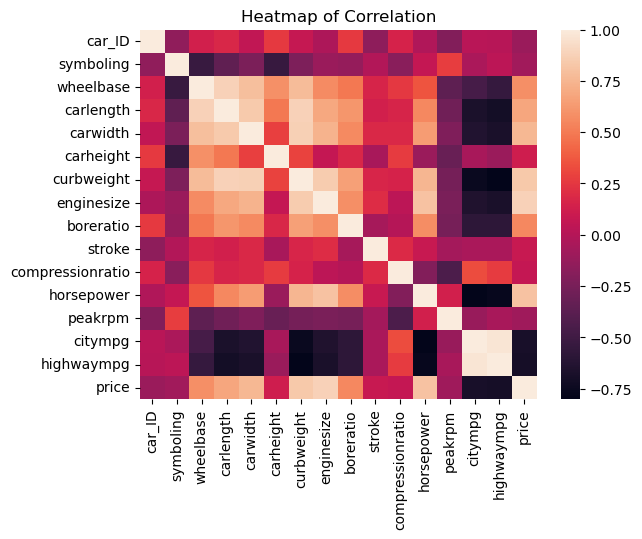

In [277]:
sns.heatmap(data.corr(numeric_only=True))
plt.title('Heatmap of Correlation')
plt.show()